# Global Weather Trend Forecasting

## Technical Assessment - Data Scientist / Analyst

### Objective
Analyze global weather data, identify meaningful patterns and anomalies, and build forecasting models to predict future weather trends.

## Basic Assesment

### Importing Data and libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns",None)

In [2]:
df=pd.read_csv("../data/GlobalWeatherRepository.csv")

### Checking Missing and Duplicated Values

In [3]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
df.shape

(153387, 41)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153387 entries, 0 to 153386
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       153387 non-null  str    
 1   location_name                 153387 non-null  str    
 2   latitude                      153387 non-null  float64
 3   longitude                     153387 non-null  float64
 4   timezone                      153387 non-null  str    
 5   last_updated_epoch            153387 non-null  int64  
 6   last_updated                  153387 non-null  str    
 7   temperature_celsius           153387 non-null  float64
 8   temperature_fahrenheit        153387 non-null  float64
 9   condition_text                153387 non-null  str    
 10  wind_mph                      153387 non-null  float64
 11  wind_kph                      153387 non-null  float64
 12  wind_degree                   153387 non-null  int64  


In [6]:
df.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [7]:
df.duplicated().sum()

np.int64(0)

Observation: No missing values or duplicate records were found in the dataset. Therefore, no imputation or duplicate removal was required.

### Redundant Feature Removal: 
Seven columns representing weather measurements in alternative imperial units were removed. Equivalent metric measurements were retained to reduce redundancy while preserving the underlying information. The remaining features were retained because they may contribute to forecasting, environmental, spatial, or geographical analyses.

In [8]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated_epoch', 'last_updated', 'temperature_celsius',
       'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in',
       'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius',
       'feels_like_fahrenheit', 'visibility_km', 'visibility_miles',
       'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide',
       'air_quality_Ozone', 'air_quality_Nitrogen_dioxide',
       'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10',
       'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise',
       'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

In [9]:
#Dropping Unwanted Columns
unwanted_cols=[
    'temperature_fahrenheit',
    'wind_mph',
    'pressure_in',
    'precip_in',
    'feels_like_fahrenheit',
    'visibility_miles',
    'gust_mph',
    'last_updated_epoch'
]

df.drop(columns=unwanted_cols, inplace=True)
df.shape

(153387, 33)

In [10]:
#Converting last_updated to datetime
df["last_updated"]=pd.to_datetime(df["last_updated"])

df["last_updated"].dtype

dtype('<M8[us]')

### Outlier Detection and Handling

Potential outliers in key continuous weather variables were examined using the Interquartile Range (IQR) method. Since extreme weather conditions may represent genuine observations rather than data errors, detected outliers were analyzed before deciding whether removal or treatment was necessary.

In [11]:
df.columns

Index(['country', 'location_name', 'latitude', 'longitude', 'timezone',
       'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph',
       'wind_degree', 'wind_direction', 'pressure_mb', 'precip_mm', 'humidity',
       'cloud', 'feels_like_celsius', 'visibility_km', 'uv_index', 'gust_kph',
       'air_quality_Carbon_Monoxide', 'air_quality_Ozone',
       'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index',
       'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise',
       'moonset', 'moon_phase', 'moon_illumination'],
      dtype='str')

In [12]:
outlier_columns = [
    "temperature_celsius",
    "wind_kph",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "visibility_km",
    "gust_kph"
]

outlier_summary = []

for column in outlier_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": column,
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage": round(len(outliers) / len(df) * 100, 2)
    })

pd.DataFrame(outlier_summary)

,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,temperature_celsius,-1.60,45.60,2983,1.94
1,wind_kph,-11.15,34.85,2560,1.67
2,pressure_mb,998.00,1030.00,4252,2.77
3,precip_mm,-0.03,0.05,30801,20.08
4,humidity,1.00,137.00,0,0.00
5,visibility_km,10.00,10.00,32363,21.10
6,gust_kph,-11.00,45.00,4091,2.67


### Data Normalization

Selected continuous numerical features were normalized using Min-Max scaling, transforming their values to a range between 0 and 1. The original dataset was preserved for exploratory analysis and interpretation, while the normalized data can be used for models that are sensitive to feature scales.

In [13]:
from sklearn.preprocessing import MinMaxScaler

features= [
    "temperature_celsius",
    "wind_kph",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "cloud",
    "feels_like_celsius",
    "visibility_km",
    "uv_index",
    "gust_kph"
]


df_normalized = df.copy()

scaler = MinMaxScaler()

df_normalized[features] = scaler.fit_transform(
    df[features]
)

df_normalized[features].head()

,temperature_celsius,wind_kph,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph
0,0.516957,0.003277,0.031569,0.000000,0.224490,0.30,0.525424,0.3125,0.429448,0.003944
1,0.447296,0.002568,0.031569,0.002367,0.938776,0.75,0.472034,0.3125,0.306748,0.004989
2,0.483960,0.003886,0.031083,0.000000,0.275510,0.00,0.519492,0.3125,0.306748,0.006303
3,0.330889,0.002804,0.029140,0.007102,0.602041,1.00,0.343220,0.0625,0.122699,0.003404
4,0.511457,0.003176,0.031083,0.000000,0.887755,0.50,0.554237,0.3125,0.490798,0.005595


### 2. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution, relationships, trends, and patterns present in the global weather data.

In [14]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,153387.0,19.242945,-41.3,4.0503,17.25,40.4,65.3,24.398169
longitude,153387.0,21.881857,-175.2,-6.8361,21.4333,49.8822,179.22,65.778116
last_updated,153387,2025-06-15 13:48:16.268262,2024-05-16 01:45:00,2024-11-30 12:45:00,2025-06-15 11:45:00,2025-12-29 08:00:00,2026-07-15 19:00:00,NaN
temperature_celsius,153387.0,21.359493,-29.8,16.1,23.7,27.9,79.3,9.487665
wind_kph,153387.0,12.780785,3.6,6.1,10.8,17.6,2963.2,11.257515
wind_degree,153387.0,169.573321,1.0,81.0,162.0,256.0,360.0,103.529354
pressure_mb,153387.0,1014.058036,947.0,1010.0,1014.0,1018.0,3006.0,9.95491
precip_mm,153387.0,0.131786,0.0,0.0,0.0,0.02,42.24,0.557926
humidity,153387.0,66.958419,2.0,52.0,72.0,86.0,100.0,23.633807
cloud,153387.0,39.511732,0.0,0.0,27.0,75.0,100.0,34.094791


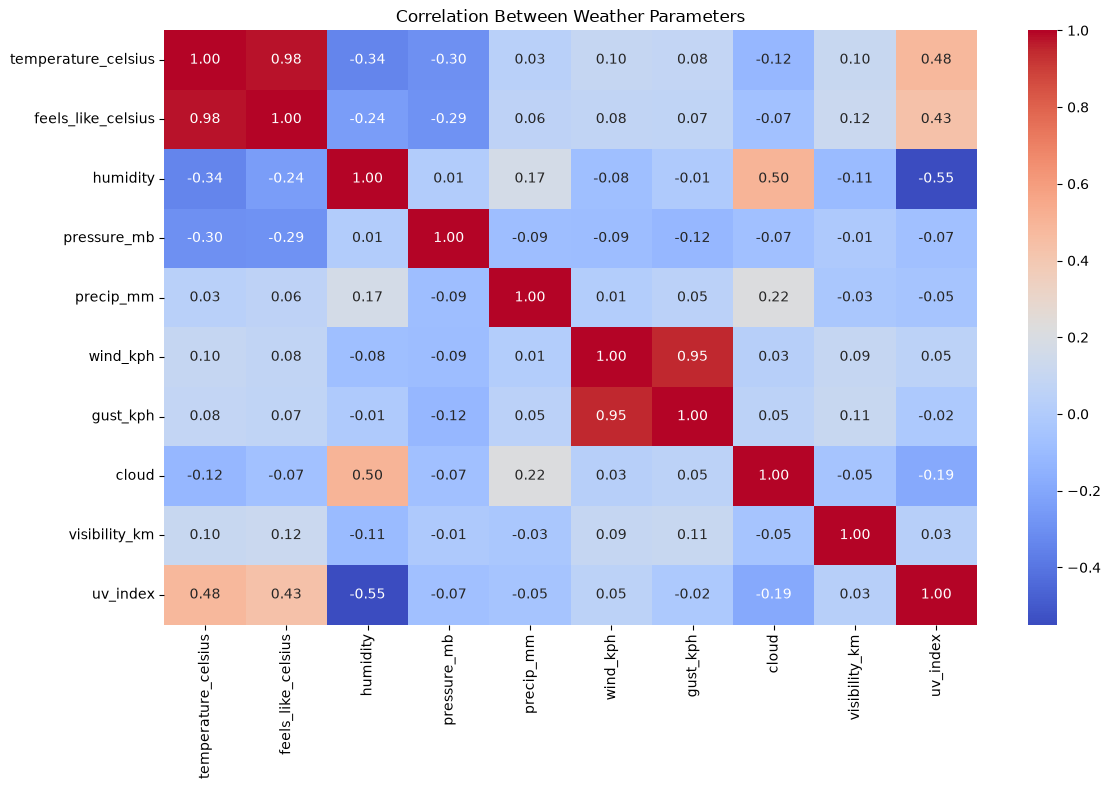

In [15]:
# Select meaningful continuous weather features
eda_features = [
    "temperature_celsius",
    "feels_like_celsius",
    "humidity",
    "pressure_mb",
    "precip_mm",
    "wind_kph",
    "gust_kph",
    "cloud",
    "visibility_km",
    "uv_index"
]

correlation_matrix = df[eda_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Weather Parameters")
plt.tight_layout()
plt.show()

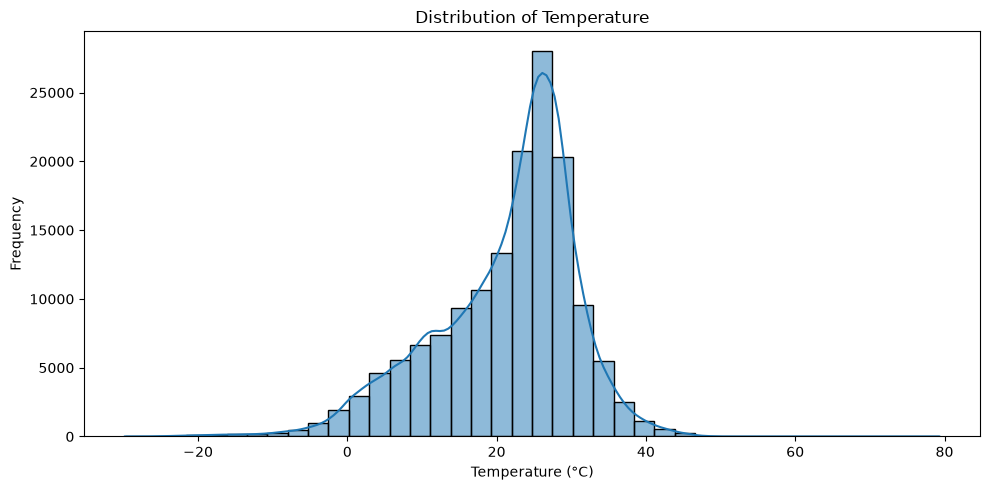

In [16]:
#Temperature Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="temperature_celsius",
    bins=40,
    kde=True
)

plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

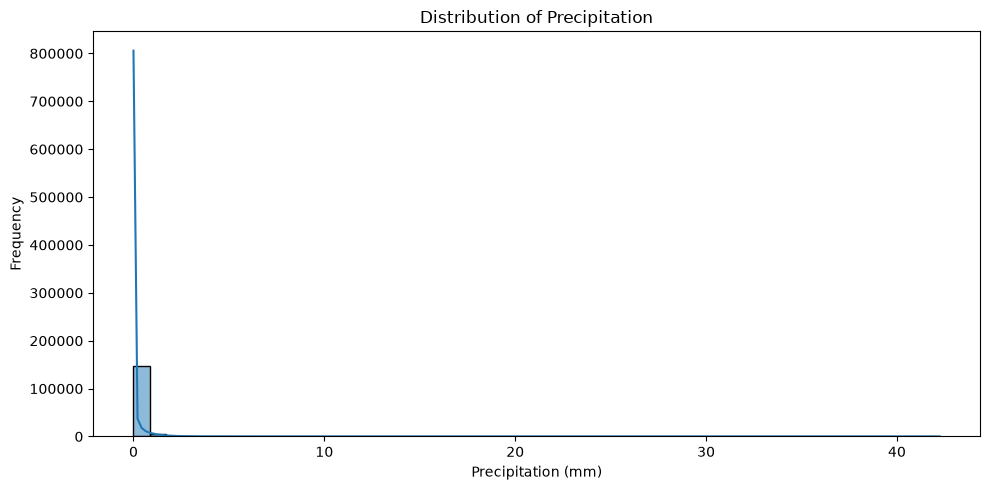

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="precip_mm",
    bins=50,
    kde=True
)

plt.title("Distribution of Precipitation")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

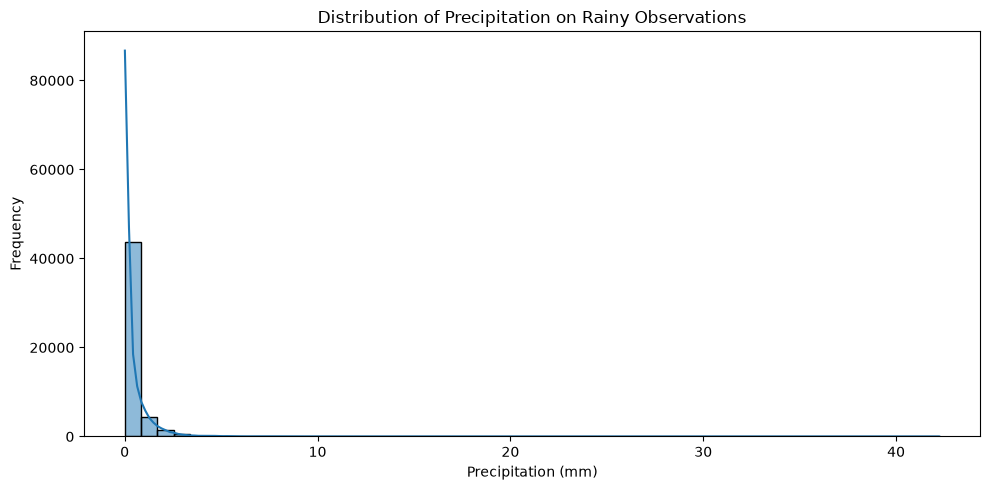

In [18]:
#Considering only Rainy data
rainy_data = df[df["precip_mm"] > 0]

plt.figure(figsize=(10, 5))

sns.histplot(
    data=rainy_data,
    x="precip_mm",
    bins=50,
    kde=True
)

plt.title("Distribution of Precipitation on Rainy Observations")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

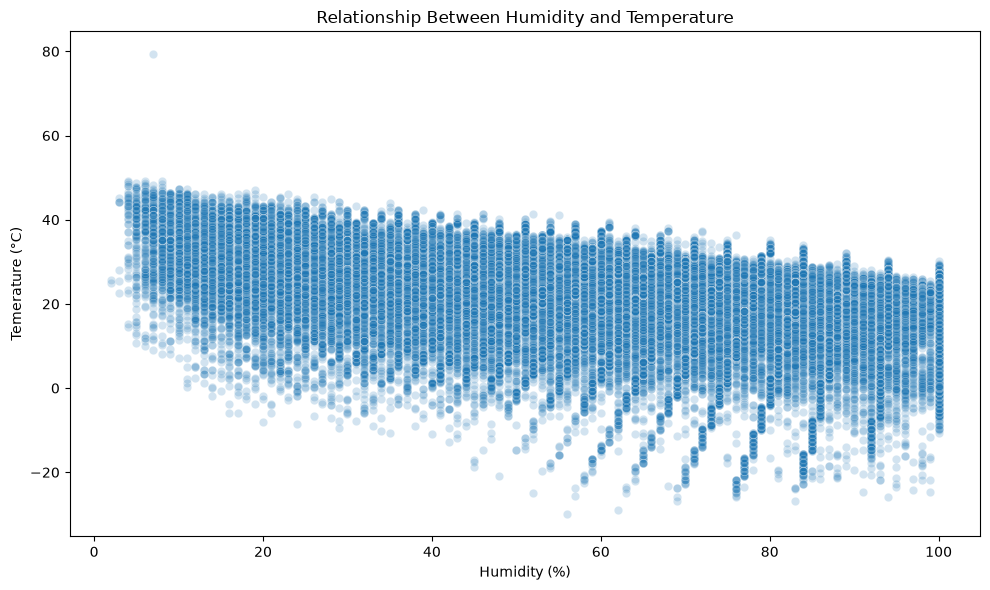

In [19]:
#Temperature vs Humidity
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="humidity",
    y="temperature_celsius",
    alpha=0.2
)

plt.title("Relationship Between Humidity and Temperature")
plt.xlabel("Humidity (%)")
plt.ylabel("Temerature (°C)")
plt.tight_layout()
plt.show

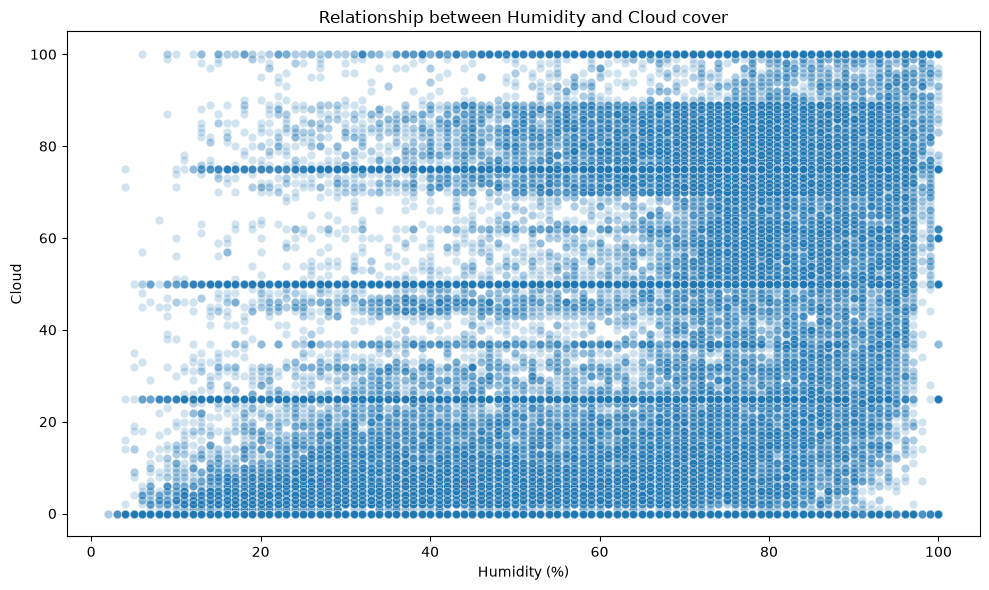

In [20]:
#Humidity vs Cloud 
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="humidity",
    y="cloud",
    alpha=0.2
)

plt.title("Relationship between Humidity and Cloud cover")
plt.xlabel("Humidity (%)")
plt.ylabel("Cloud")
plt.tight_layout()
plt.show()

### Building basic model

In [21]:
print("Start:", df["last_updated"].min())
print("End:", df["last_updated"].max())
print("Unique dates:", df["last_updated"].dt.date.nunique())

df.groupby(["country", "location_name"]).size().sort_values(ascending=False).head(10)

Start: 2024-05-16 01:45:00
End: 2026-07-15 19:00:00
Unique dates: 790


country            location_name
Burundi            Bujumbura        789
Ukraine            Kyiv             789
Yemen              Sanaa            789
Chad               N'djamena        789
Ghana              Accra            789
Fiji Islands       Suva             789
Eritrea            Asmara           789
Equatorial Guinea  Malabo           789
Uzbekistan         Tashkent         789
Vatican City       Vatican City     789
dtype: int64

In [22]:
df[df["country"] == "India"]["location_name"].unique()

<StringArray>
['New Delhi']
Length: 1, dtype: str

In [23]:
delhi_df = df[
    (df["country"] == "India") &
    (df["location_name"] == "New Delhi")
].copy()

delhi_df = delhi_df.sort_values("last_updated")

print("Number of observations:", len(delhi_df))
print("Start:", delhi_df["last_updated"].min())
print("End:", delhi_df["last_updated"].max())

delhi_df[["last_updated", "temperature_celsius"]].head()

Number of observations: 786
Start: 2024-05-16 14:15:00
End: 2026-07-15 11:30:00


,last_updated,temperature_celsius
77,2024-05-16 14:15:00,42.0
272,2024-05-16 19:30:00,38.0
467,2024-05-17 21:30:00,36.0
659,2024-05-18 20:00:00,41.0
853,2024-05-19 19:45:00,41.0


In [24]:
# Create a date column without the time component
delhi_df["date"] = delhi_df["last_updated"].dt.normalize()

# Average temperature for each day
delhi_daily = (
    delhi_df.groupby("date")["temperature_celsius"]
    .mean()
    .reset_index()
)

print("Daily observations:", len(delhi_daily))
delhi_daily.head()

Daily observations: 785


,date,temperature_celsius
0,2024-05-16,40.0
1,2024-05-17,36.0
2,2024-05-18,41.0
3,2024-05-19,41.0
4,2024-05-20,40.0


In [25]:
expected_dates = pd.date_range(
    start=delhi_daily["date"].min(),
    end=delhi_daily["date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(delhi_daily["date"])

print("Expected number of days:", len(expected_dates))
print("Actual number of days:", len(delhi_daily))
print("Missing days:", len(missing_dates))

missing_dates[:10]

Expected number of days: 791
Actual number of days: 785
Missing days: 6


DatetimeIndex(['2024-06-19', '2024-07-13', '2024-07-21', '2024-07-22',
               '2026-01-19', '2026-03-09'],
              dtype='datetime64[us]', freq=None)

In [26]:
delhi_daily = delhi_daily.set_index("date")

delhi_daily = delhi_daily.reindex(expected_dates)

print("Missing temperatures before interpolation:")
print(delhi_daily["temperature_celsius"].isnull().sum())

Missing temperatures before interpolation:
6


In [27]:
delhi_daily["temperature_celsius"] = (
    delhi_daily["temperature_celsius"]
    .interpolate(method="time")
)

print("Missing temperatures after interpolation:")
print(delhi_daily["temperature_celsius"].isnull().sum())

Missing temperatures after interpolation:
0


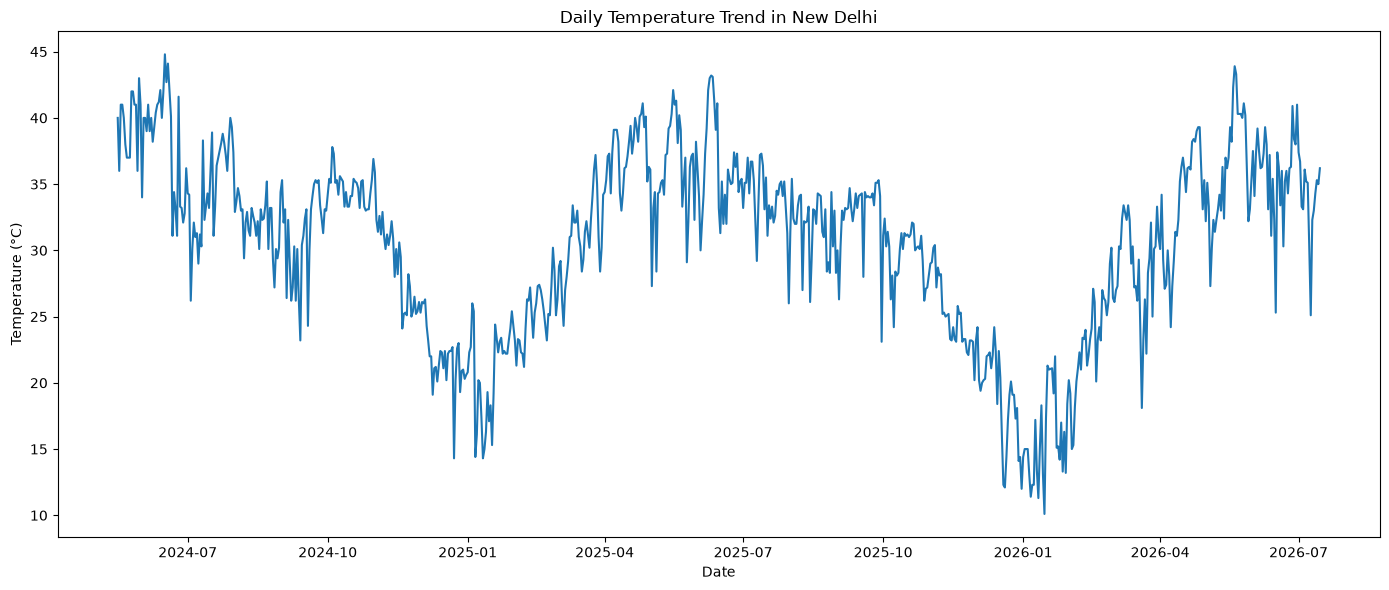

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    delhi_daily.index,
    delhi_daily["temperature_celsius"]
)

plt.title("Daily Temperature Trend in New Delhi")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    delhi_daily,
    test_size=90,
    shuffle=False
)

print("Training data:", train.shape)
print("Testing data:", test.shape)

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

Training data: (701, 1)
Testing data: (90, 1)
Train period: 2024-05-16 00:00:00 to 2026-04-16 00:00:00
Test period: 2026-04-17 00:00:00 to 2026-07-15 00:00:00


In [30]:
train["day_of_year"] = train.index.dayofyear
train["year"] = train.index.year

In [31]:
test["day_of_year"] = test.index.dayofyear
test["year"] = test.index.year

In [32]:
# Create cyclical seasonal features
train["day_sin"] = np.sin(2 * np.pi * train["day_of_year"] / 365.25)
train["day_cos"] = np.cos(2 * np.pi * train["day_of_year"] / 365.25)

test["day_sin"] = np.sin(2 * np.pi * test["day_of_year"] / 365.25)
test["day_cos"] = np.cos(2 * np.pi * test["day_of_year"] / 365.25)

In [33]:
X_train = train[["day_sin", "day_cos", "year"]]
X_test = test[["day_sin", "day_cos", "year"]]

y_train = train["temperature_celsius"]
y_test = test["temperature_celsius"]

In [34]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 1.42,-6.98,-2.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['day_sin','day_cos','year']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4869
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [35]:
y_pred=lr.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

evaluation = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [mae, rmse, r2]
})

evaluation

,Metric,Value
0,MAE,3.622330
1,RMSE,4.486968
2,R² Score,-0.677380


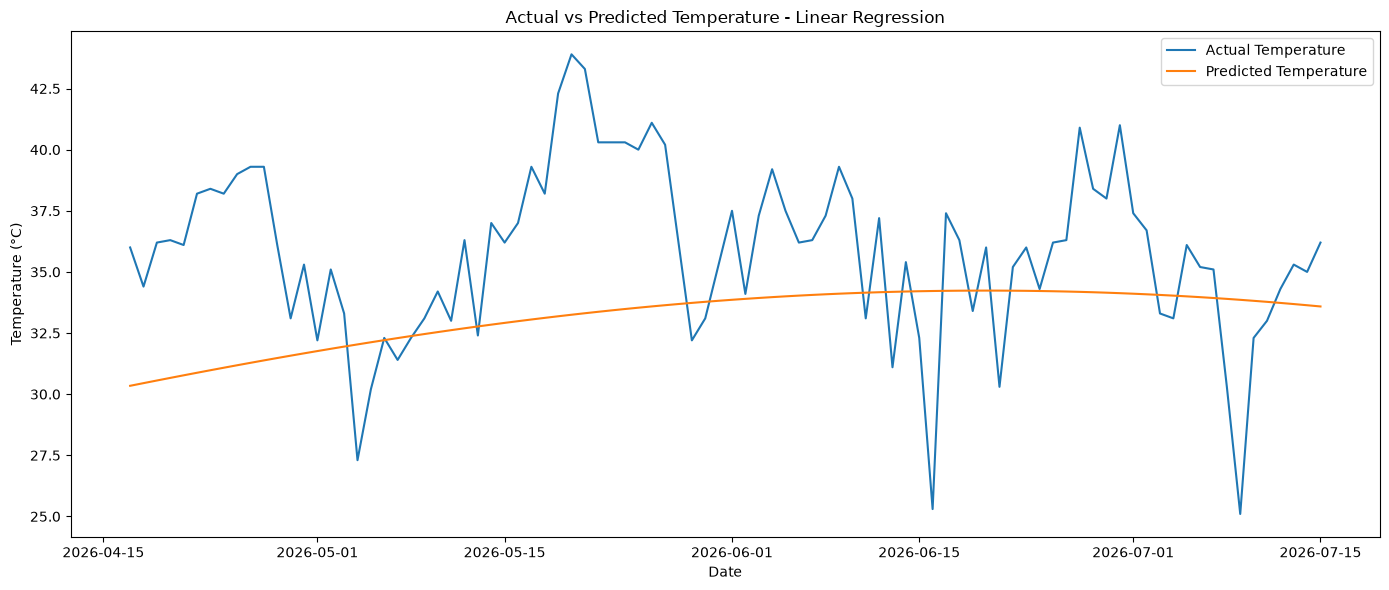

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    y_test,
    label="Actual Temperature"
)

plt.plot(
    test.index,
    y_pred,
    label="Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature - Linear Regression")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## Advanced

### Anamoly detection

In [38]:
anomaly_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm"
]

X_anomaly = df[anomaly_features].copy()

X_anomaly.head()

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm
0,26.6,24,1012.0,13.3,0.0
1,19.0,94,1012.0,11.2,0.1
2,23.0,29,1011.0,15.1,0.0
3,6.3,61,1007.0,11.9,0.3
4,26.0,89,1011.0,13.0,0.0


In [39]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_anomaly_scaled=scaler.fit_transform(X_anomaly)

In [40]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["anomaly"] = iso_forest.fit_predict(X_anomaly_scaled)

In [41]:
df["anomaly"].value_counts()

anomaly
 1    150319
-1      3068
Name: count, dtype: int64

In [42]:
anomalies = df[df["anomaly"] == -1]

anomalies[
    [
        "country",
        "location_name",
        "temperature_celsius",
        "humidity",
        "pressure_mb",
        "wind_kph",
        "precip_mm"
    ]
].head(10)

,country,location_name,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm
176,Tonga,Nuku`Aloia,23.0,100,1016.0,33.1,2.09
219,Brunei Darussalam,Bandar Seri Begawan,27.0,100,1010.0,11.2,3.01
317,Netherlands,Amsterdam,20.0,68,1003.0,20.2,2.42
490,Luxembourg,Luxembourg,12.0,94,1008.0,25.9,1.70
746,Sri Lanka,Colombo,25.0,100,1007.0,9.0,3.21
852,Iceland,Grindavik,4.0,87,1007.0,46.1,1.00
880,Maldives,Felidhoo,28.8,80,1008.0,40.3,1.02
935,Solomon Islands,Honiara,25.0,94,1008.0,3.6,13.05
1289,New Zealand,Wellington,11.0,94,1009.0,56.2,0.66
1294,Macedonia,Skopje,27.0,58,1010.0,33.1,1.72


In [43]:
df.groupby("anomaly")[anomaly_features].mean().round(2)

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm
anomaly,,,,,
-1,15.67,74.57,1006.66,21.67,1.93
1,21.48,66.80,1014.21,12.60,0.10


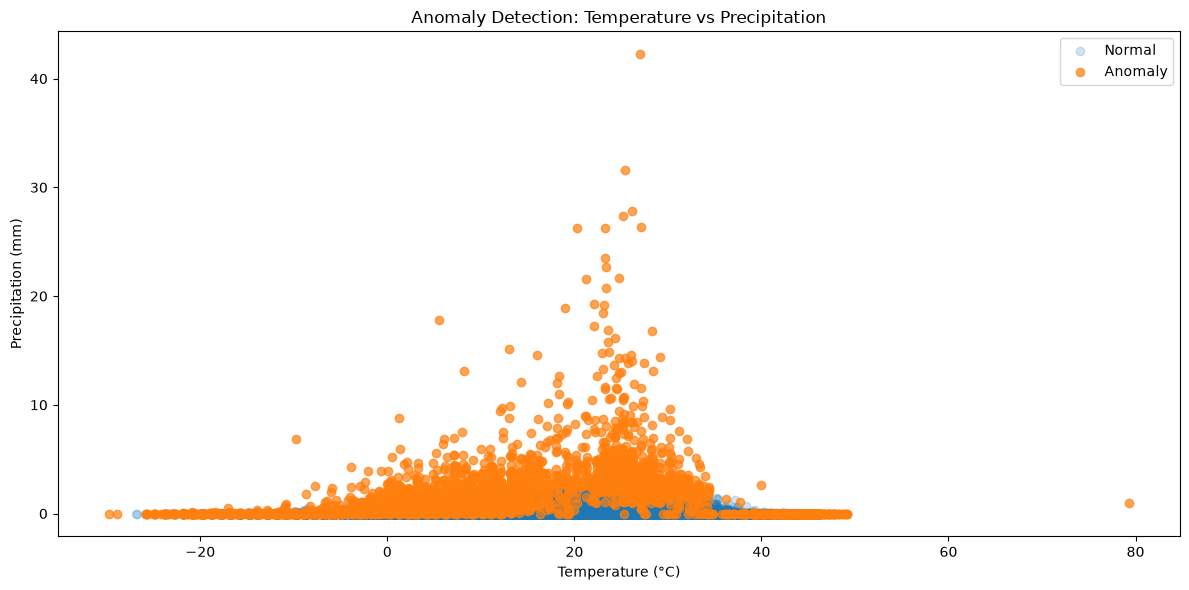

In [44]:
plt.figure(figsize=(12, 6))

normal = df[df["anomaly"] == 1]
anomalies = df[df["anomaly"] == -1]

plt.scatter(
    normal["temperature_celsius"],
    normal["precip_mm"],
    alpha=0.2,
    label="Normal"
)

plt.scatter(
    anomalies["temperature_celsius"],
    anomalies["precip_mm"],
    alpha=0.7,
    label="Anomaly"
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Precipitation (mm)")
plt.title("Anomaly Detection: Temperature vs Precipitation")
plt.legend()
plt.tight_layout()
plt.show()

### Training Using Decision Tree Regressor

In [45]:
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor(
    random_state=42
)
dt.fit(X_train, y_train)

y_pred_dt=dt.predict(X_test)

In [46]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE: 3.4444444444444446
RMSE: 4.188343613198685
R² Score: -0.46153849318726325


### Training Using Random Forest Regressor

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf=rf.predict(X_test)

In [48]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE: 2.84836666666667
RMSE: 3.5158182436272547
R² Score: -0.029860687996525526


### Training Using KNN

In [49]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [50]:
from sklearn.neighbors import KNeighborsRegressor

knn=KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn=knn.predict(X_test_scaled)

In [51]:
knn_mae = mean_absolute_error(y_test, y_pred_knn)
knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
knn_r2 = r2_score(y_test, y_pred_knn)

print("KNN Results")
print("MAE:", knn_mae)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)

KNN Results
MAE: 2.842888888888888
RMSE: 3.624837161093507
R² Score: -0.09471899234773073


### Training using Support Vector Regressor

In [52]:
from sklearn.svm import SVR

svr=SVR(kernel="rbf")

svr.fit(X_train_scaled, y_train)

y_pred_svr=svr.predict(X_test_scaled)

In [53]:
svr_mae = mean_absolute_error(y_test, y_pred_svr)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr))
svr_r2 = r2_score(y_test, y_pred_svr)

print("SVR Results")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)

SVR Results
MAE: 5.135849800281692
RMSE: 5.865517153389898
R² Score: -1.8664097220447822


### Comparison Of Models

In [54]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "KNN Regressor",
        "Support Vector Regressor"
    ],

    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        knn_mae,
        svr_mae
    ],

    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        knn_rmse,
        svr_rmse
    ],

    "R2 Score": [
        r2,
        dt_r2,
        rf_r2,
        knn_r2,
        svr_r2
    ]
})

# Round values for better readability
model_comparison = model_comparison.round(3)

# Sort by RMSE 
model_comparison = model_comparison.sort_values(
    by="RMSE"
).reset_index(drop=True)

model_comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,2.848,3.516,-0.030
1,KNN Regressor,2.843,3.625,-0.095
2,Decision Tree Regressor,3.444,4.188,-0.462
3,Linear Regression,3.622,4.487,-0.677
4,Support Vector Regressor,5.136,5.866,-1.866


### Ensemble of Random Forest Prediction and KNN Prediction

In [55]:
ensemble_pred=(y_pred_rf + y_pred_knn)/2

In [56]:
ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_pred))
ensemble_r2 = r2_score(y_test, ensemble_pred)

print("Ensemble Results")
print("MAE:", ensemble_mae)
print("RMSE:", ensemble_rmse)
print("R² Score:", ensemble_r2)

Ensemble Results
MAE: 2.519061111111111
RMSE: 3.329019247048931
R² Score: 0.07666720332286692


In [57]:
ensemble_row = pd.DataFrame({
    "Model": ["RF + KNN Ensemble"],
    "MAE": [ensemble_mae],
    "RMSE": [ensemble_rmse],
    "R2 Score": [ensemble_r2]
})

final_model_comparison = pd.concat(
    [model_comparison, ensemble_row],
    ignore_index=True
)

final_model_comparison = (
    final_model_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
    .round(3)
)

final_model_comparison

,Model,MAE,RMSE,R2 Score
0,RF + KNN Ensemble,2.519,3.329,0.077
1,Random Forest Regressor,2.848,3.516,-0.030
2,KNN Regressor,2.843,3.625,-0.095
3,Decision Tree Regressor,3.444,4.188,-0.462
4,Linear Regression,3.622,4.487,-0.677
5,Support Vector Regressor,5.136,5.866,-1.866


### Climate Analysis

In [58]:
cities_to_check = [
    "New Delhi",
    "London",
    "Tokyo",
    "Cairo",
    "Sydney"
]

df[df["location_name"].isin(cities_to_check)][
    ["country", "location_name"]
].drop_duplicates()

,country,location_name
51,Egypt,Cairo
77,India,New Delhi
85,Japan,Tokyo
185,United Kingdom,London
11512,Inde,New Delhi


In [59]:
climate_cities = ["New Delhi", "London", "Tokyo", "Cairo"]

climate_df = df[
    df["location_name"].isin(climate_cities)
].copy()

# Create month from last_updated
climate_df["month"] = (
    climate_df["last_updated"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Calculate monthly average temperature for each city
monthly_climate = (
    climate_df
    .groupby(["month", "location_name"])["temperature_celsius"]
    .mean()
    .reset_index()
)

monthly_climate.head()

,month,location_name,temperature_celsius
0,2024-05-01,Cairo,33.588235
1,2024-05-01,London,17.058824
2,2024-05-01,New Delhi,39.588235
3,2024-05-01,Tokyo,20.523529
4,2024-06-01,Cairo,37.846667


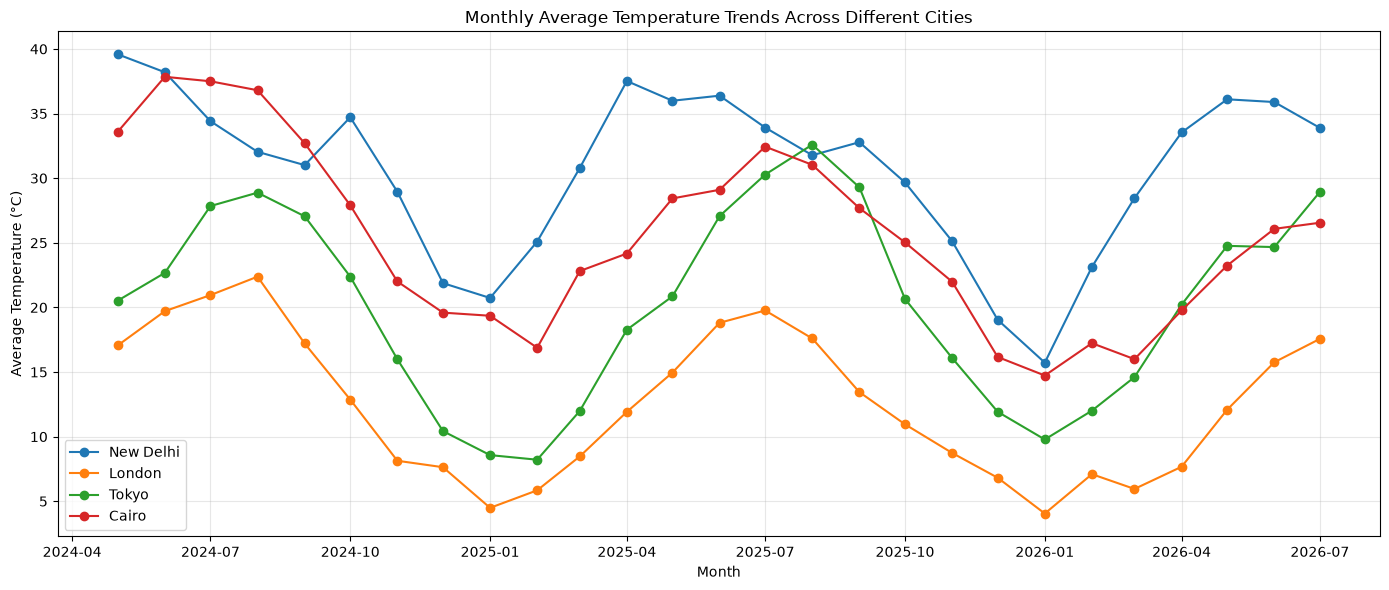

In [60]:
plt.figure(figsize=(14, 6))

for city in climate_cities:
    city_data = monthly_climate[
        monthly_climate["location_name"] == city
    ]

    plt.plot(
        city_data["month"],
        city_data["temperature_celsius"],
        marker="o",
        label=city
    )

plt.title("Monthly Average Temperature Trends Across Different Cities")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Environmental Impact

In [61]:
air_quality_features = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10"
]

weather_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm"
]

environmental_corr = df[
    air_quality_features + weather_features
].corr()

environmental_corr

,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm
air_quality_Carbon_Monoxide,1.000000,-0.083271,0.606640,0.341847,0.610387,0.163060,-0.004005,-0.076121,0.017147,-0.099736,0.010033
air_quality_Ozone,-0.083271,1.000000,-0.230252,-0.033198,0.046292,0.090579,0.252352,-0.404964,-0.106630,0.118824,-0.058159
air_quality_Nitrogen_dioxide,0.606640,-0.230252,1.000000,0.455155,0.525118,0.186215,-0.135415,-0.108106,0.060958,-0.120546,-0.029200
air_quality_Sulphur_dioxide,0.341847,-0.033198,0.455155,1.000000,0.333448,0.143450,-0.032104,-0.115421,0.026943,-0.048030,-0.022329
air_quality_PM2.5,0.610387,0.046292,0.525118,0.333448,1.000000,0.653190,0.063547,-0.220698,0.002736,-0.035208,-0.051753
air_quality_PM10,0.163060,0.090579,0.186215,0.143450,0.653190,1.000000,0.113988,-0.243097,-0.024660,0.060297,-0.042683
temperature_celsius,-0.004005,0.252352,-0.135415,-0.032104,0.063547,0.113988,1.000000,-0.340287,-0.296922,0.096669,0.034264
humidity,-0.076121,-0.404964,-0.108106,-0.115421,-0.220698,-0.243097,-0.340287,1.000000,0.007480,-0.079075,0.167735
pressure_mb,0.017147,-0.106630,0.060958,0.026943,0.002736,-0.024660,-0.296922,0.007480,1.000000,-0.093671,-0.086297
wind_kph,-0.099736,0.118824,-0.120546,-0.048030,-0.035208,0.060297,0.096669,-0.079075,-0.093671,1.000000,0.009747


In [62]:
pollution_weather_corr = environmental_corr.loc[
    air_quality_features,
    weather_features
]

pollution_weather_corr.round(2)

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm
air_quality_Carbon_Monoxide,-0.00,-0.08,0.02,-0.10,0.01
air_quality_Ozone,0.25,-0.40,-0.11,0.12,-0.06
air_quality_Nitrogen_dioxide,-0.14,-0.11,0.06,-0.12,-0.03
air_quality_Sulphur_dioxide,-0.03,-0.12,0.03,-0.05,-0.02
air_quality_PM2.5,0.06,-0.22,0.00,-0.04,-0.05
air_quality_PM10,0.11,-0.24,-0.02,0.06,-0.04


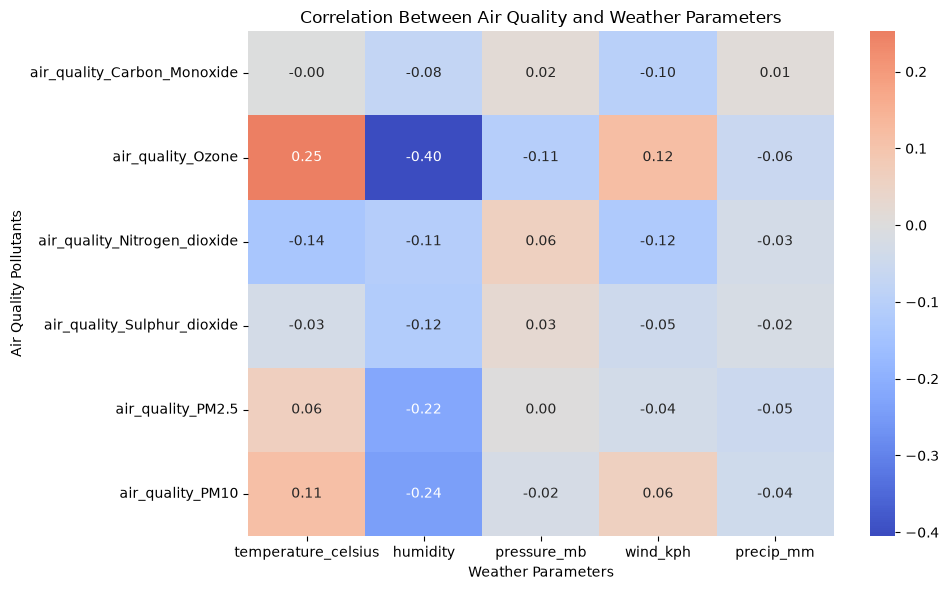

In [63]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    pollution_weather_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Air Quality and Weather Parameters")
plt.xlabel("Weather Parameters")
plt.ylabel("Air Quality Pollutants")
plt.tight_layout()
plt.show()

### Feature Importance

In [64]:
importance_features = [
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "visibility_km",
    "uv_index"
]

X_importance = df[importance_features]
y_importance = df["temperature_celsius"]

In [65]:
from sklearn.model_selection import train_test_split

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_importance,
    y_importance,
    test_size=0.2,
    random_state=42
)

In [66]:
from sklearn.ensemble import RandomForestRegressor

rf_importance = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_importance.fit(X_train_imp, y_train_imp)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [67]:
feature_importance = pd.DataFrame({
    "Feature": importance_features,
    "Importance": rf_importance.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,uv_index,0.338817
1,pressure_mb,0.261164
2,humidity,0.178396
3,wind_kph,0.085307
4,cloud,0.073719
5,visibility_km,0.033948
6,precip_mm,0.028649


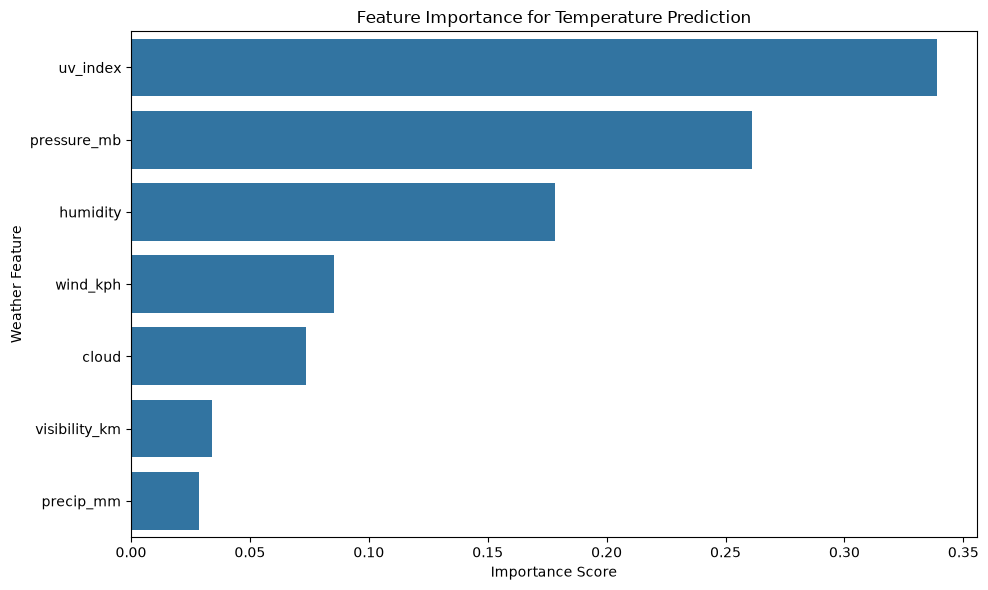

In [68]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance for Temperature Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Weather Feature")
plt.tight_layout()
plt.show()

### Spatial Analysis

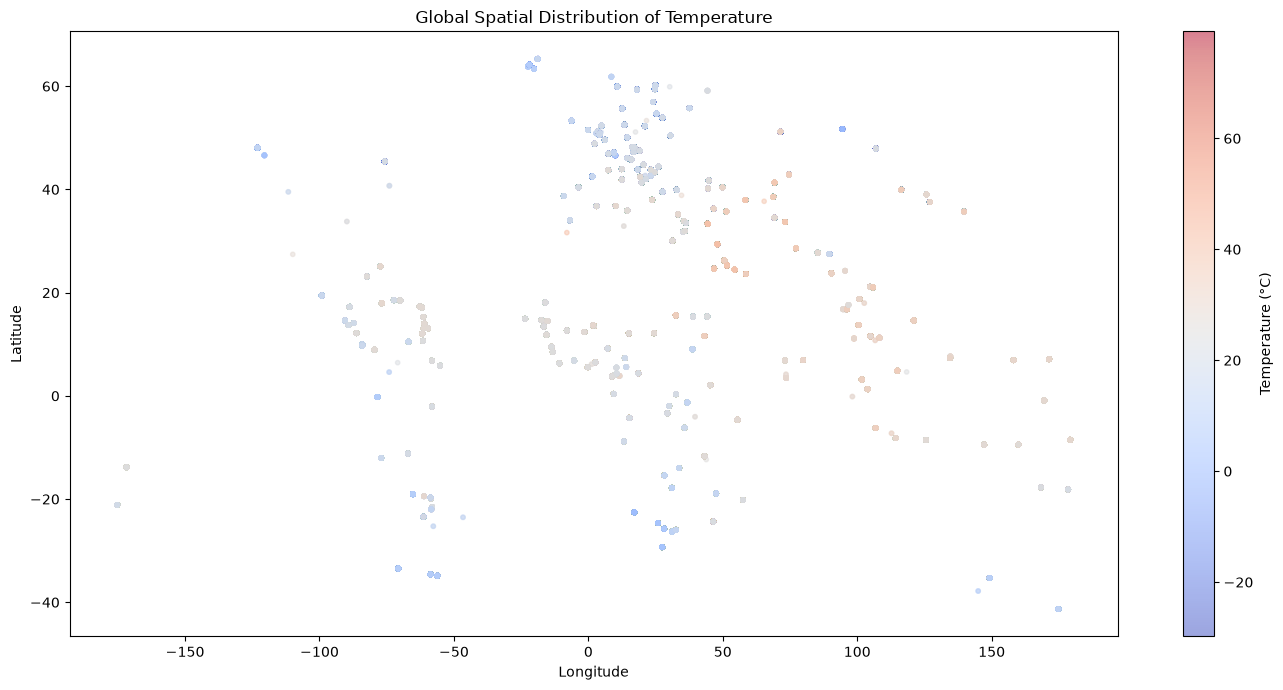

In [69]:
plt.figure(figsize=(14, 7))

scatter = plt.scatter(
    df["longitude"],
    df["latitude"],
    c=df["temperature_celsius"],
    cmap="coolwarm",
    alpha=0.5,
    s=10
)

plt.colorbar(scatter, label="Temperature (°C)")

plt.title("Global Spatial Distribution of Temperature")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

### Geographical Patterns

In [70]:
country_weather = (
    df.groupby("country")[
        [
            "temperature_celsius",
            "humidity",
            "precip_mm",
            "wind_kph"
        ]
    ]
    .mean()
    .round(2)
)

country_weather.head()

,temperature_celsius,humidity,precip_mm,wind_kph
country,,,,
Afghanistan,19.42,26.71,0.03,8.10
Albania,19.39,57.79,0.13,8.21
Algeria,20.24,65.94,0.05,12.55
Andorra,8.89,65.30,0.11,8.19
Angola,25.75,76.13,0.03,9.49


In [71]:
top_hot_countries = (
    country_weather
    .sort_values("temperature_celsius", ascending=False)
    .head(10)
    .reset_index()
)

top_hot_countries

,country,temperature_celsius,humidity,precip_mm,wind_kph
0,Saudi Arabien,45.00,7.00,0.00,24.50
1,Marrocos,40.30,14.00,0.00,16.90
2,Turkménistan,37.80,11.00,0.00,22.00
3,Турция,34.00,44.00,0.00,24.10
4,Qatar,32.56,40.37,0.00,18.87
5,United Arab Emirates,32.34,44.14,0.00,15.47
6,Cambodia,32.04,59.63,0.14,13.65
7,Oman,31.90,51.38,0.00,14.21
8,Djibouti,31.41,55.92,0.02,15.80
9,Thailand,31.25,59.00,0.22,9.77


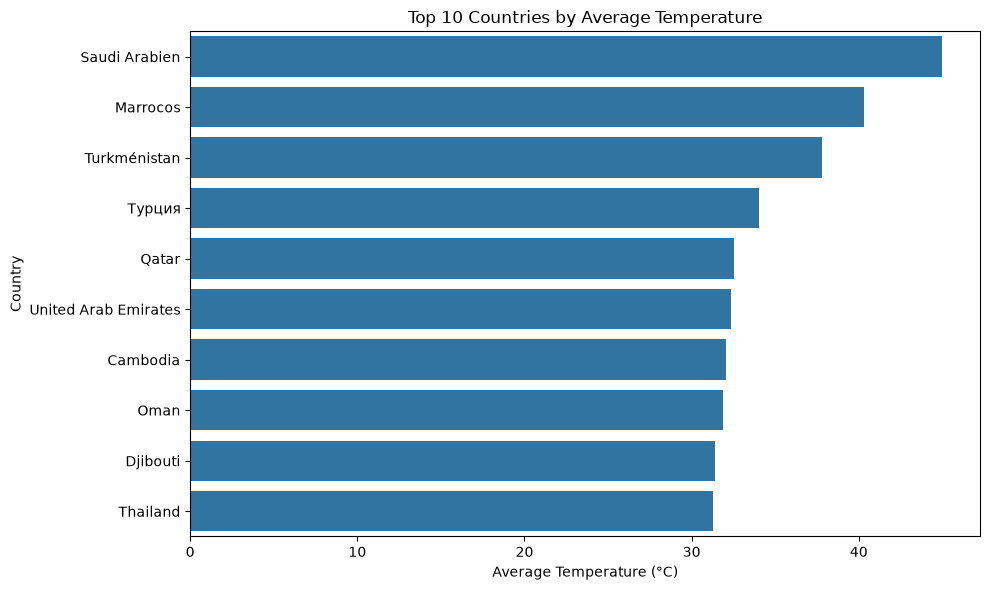

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_hot_countries,
    x="temperature_celsius",
    y="country"
)

plt.title("Top 10 Countries by Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()